# 04 · The control: predicting Sox17 and T from *density alone*

Notebook 03 produced good-looking numbers from the BMP4 mask. Notebook 02 showed the
mask also predicts local cell density. So the obvious question is whether notebook 03
measured BMP4 signalling or colony structure.

Two controls, identical model, identical splits, identical everything else:

- **density only** — smoothed cell density at the same scales. No marker channel, no
  mask, nothing derived from BMP4. Whatever this reaches is available with *no BMP4
  information at all*, and it is therefore the real baseline for notebook 03.
- **shuffled mask** — the BMP4 labels permuted across cells. Destroys the mask's
  spatial arrangement while preserving the number of positives *and* the density field
  exactly. Isolates the contribution of the mask's arrangement specifically.

There is a further reason to run this: `normalize_data=False` makes
`WeightedRadiusConv` aggregate by weighted **sum**, which is local density by
construction, so the graph has access to density whether or not it appears in
`x_cols`.

All three feature sets are cached the same way 03 caches its config C
(`recipe.load_or_fit`) -- if 03 already ran, `BMP4 mask + context` loads straight
from its checkpoint instead of retraining; `density only`/`shuffled mask` are new
here and get cached for the first time, so a second run of this notebook (or one
that reuses these paths later) is fast too.

In [ ]:
import sys, os
sys.path.append('../../src')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tools.dataset import load_well, marker_positive, IF_BACKGROUNDS, PRIMARY_WELL, MATCHED_PAIR, RESULTS
from tools.spatial import PYRAMID_SCALES
import tools.evaluation as ev
import plotting as pl

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

In [ ]:
import torch
from models import recipe
from models.graph import border_mask
from tools.spatial import add_mask_pyramid, add_density_pyramid, shuffle_mask
from tools.morphology import indices_to_mask

QUICK = False
EPOCHS = 150 if QUICK else recipe.EPOCHS
PATIENCE = 150 if QUICK else recipe.PATIENCE
CACHE_SUFFIX = '_quick' if QUICK else ''  # keeps a provisional run from being reused as the real one

df = load_well(PRIMARY_WELL)
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)
IF_COLS = ['Sox17_mean', 'T_mean']

X_MASK = recipe.mask_features(df, 'BMP4_bin', max_sigma=recipe.MAX_SIGMA, geometry=True)
X_DENSITY = recipe.density_features(df, max_sigma=recipe.MAX_SIGMA)

shuffle_mask(df, 'BMP4_bin', seed=0, out_col='mask_shuffled')
X_SHUFFLED = recipe.mask_features(df, 'mask_shuffled', max_sigma=recipe.MAX_SIGMA, geometry=True)

FEATURE_SETS = {
    'BMP4 mask + context': X_MASK,
    'density only':        X_DENSITY,
    'shuffled mask':       X_SHUFFLED,
}
# same slug 03 uses for 'BMP4 mask + context' ('mask') -- so that arm's checkpoint
# path matches 03's exactly and this notebook loads it instead of retraining
SLUGS = {'BMP4 mask + context': 'mask', 'density only': 'density', 'shuffled mask': 'shuffled'}
for k, v in FEATURE_SETS.items():
    print(f'{k:22s} {len(v):2d} features')

BMP4 mask + context     8 features
density only            5 features
shuffled mask           8 features


## What the density features look like

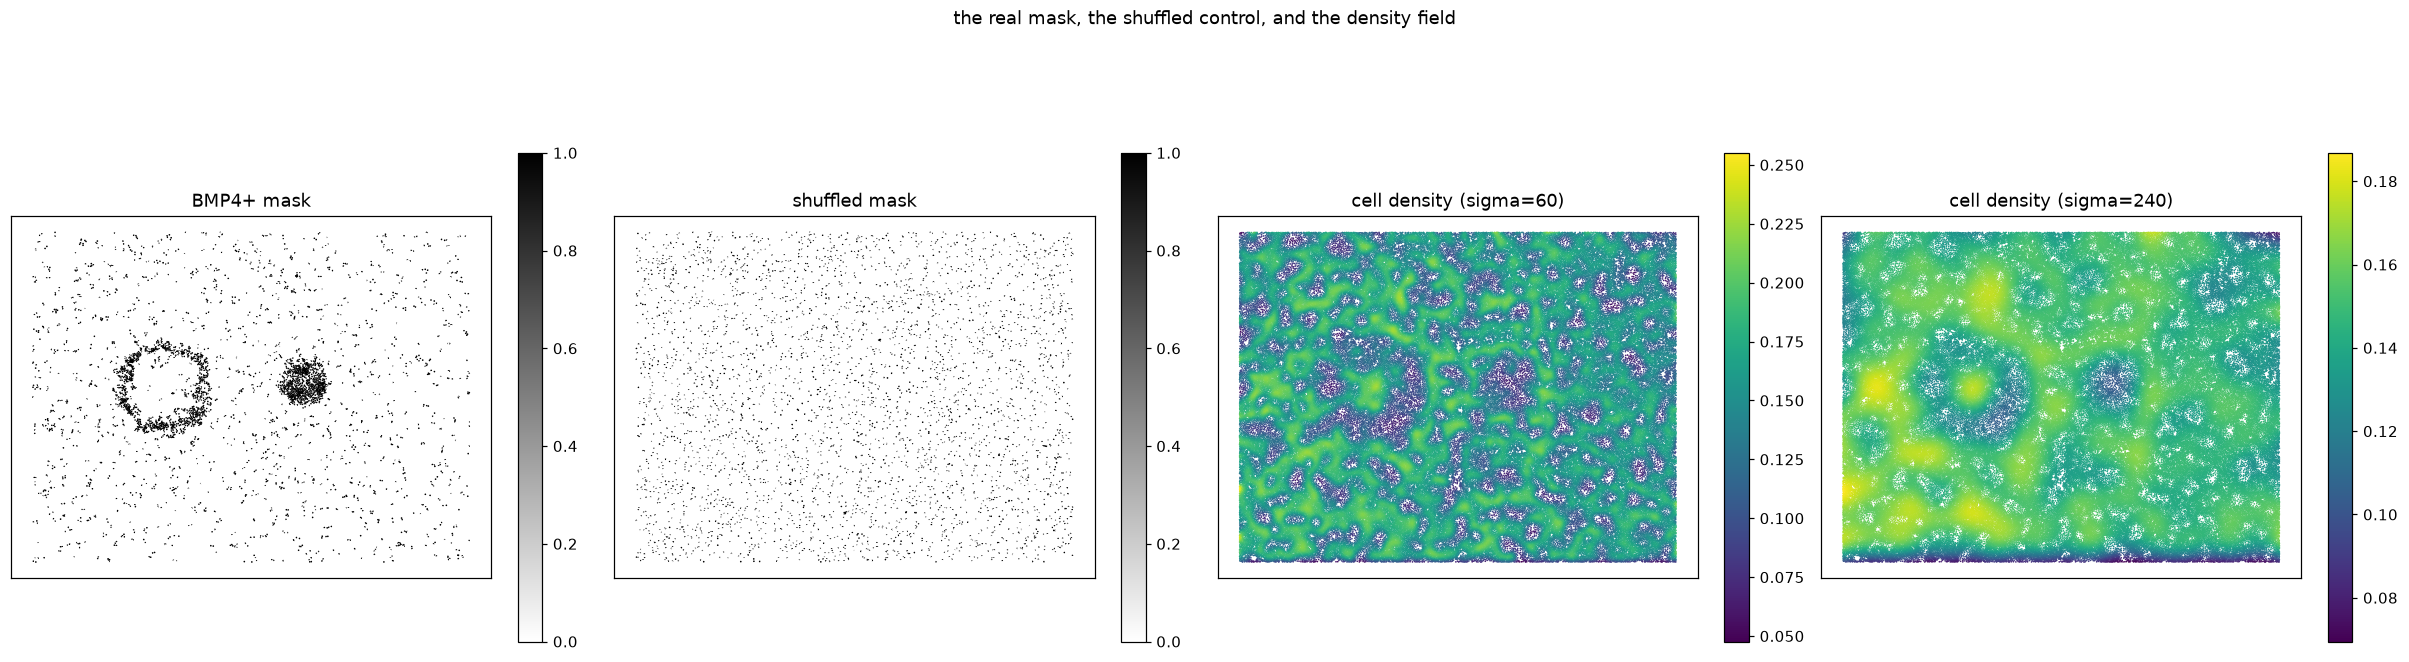

In [ ]:
fig = pl.plot_cell_maps(df, [
    ('BMP4+ mask', 'BMP4_bin', 'gray_r'),
    ('shuffled mask', 'mask_shuffled', 'gray_r'),
    ('cell density (sigma=60)', 'dens_60', 'viridis'),
    ('cell density (sigma=240)', 'dens_240', 'viridis'),
], suptitle='the real mask, the shuffled control, and the density field')
plt.show()

In [ ]:
shape = (int(centroids[:,0].max())+2, int(centroids[:,1].max())+2)
valid = np.where(~border_mask(centroids, shape, recipe.RADIUS))[0]
SPLITS = {
    'random':  tuple(valid[i] for i in ev.random_split(len(valid), seed=0)),
    'blocked': tuple(valid[i] for i in ev.spatial_block_split(centroids[valid], block=800.0, seed=0)),
}
N = len(df)
MASKS = {k: tuple(indices_to_mask(i, N) for i in v) for k, v in SPLITS.items()}

ceilings = pd.read_pickle(f'{RESULTS}/oracle_ceilings.pkl')

In [ ]:
rows, fitted = [], {}
for marker in ['Sox17', 'T']:
    y_col = f'{marker}_mean'
    for split_name in SPLITS:
        tr, va, te = SPLITS[split_name]
        trm, vam, tem = MASKS[split_name]
        for fname, cols in FEATURE_SETS.items():
            cache_path = f'{RESULTS}/models/{PRIMARY_WELL}_{SLUGS[fname]}_{marker}_{split_name}{CACHE_SUFFIX}_gnn.pt'
            model, data, log_w, history = recipe.load_or_fit(
                cache_path, df, cols, y_col, trm, vam, tr, IF_COLS, custom_background=IF_BACKGROUNDS,
                epochs=EPOCHS, patience=PATIENCE, verbose=False)
            pred = recipe.predict(model, data, log_w)
            y = data['y'].numpy().ravel(); ypos = data['y_positive'].numpy().ravel()
            t = tem.numpy()
            met = ev.evaluate(y[t], pred[t], ypos[t])
            rows.append(dict(target=marker, split=split_name, features=fname, **met))
            fitted[(marker, split_name, fname)] = dict(model=model, data=data, pred=pred,
                                                       y=y, ypos=ypos, history=history)
            print(f'{marker:6s} {split_name:8s} {fname:22s} '
                  f'R2={met["r2"]:+.4f}  AUROC={met["auroc"]:.3f}')

control_results = pd.DataFrame(rows)
control_results.round(4)

Sox17  random   BMP4 mask + context    R2=+0.1019  AUROC=0.716
Sox17  random   density only           R2=+0.0736  AUROC=0.701
Sox17  random   shuffled mask          R2=+0.0704  AUROC=0.699
Sox17  blocked  BMP4 mask + context    R2=+0.0554  AUROC=0.690
Sox17  blocked  density only           R2=+0.0099  AUROC=0.610
Sox17  blocked  shuffled mask          R2=-0.0039  AUROC=0.605
T      random   BMP4 mask + context    R2=+0.2326  AUROC=0.790
T      random   density only           R2=+0.2385  AUROC=0.792


KeyboardInterrupt: 

In [ ]:
for marker in ['Sox17', 'T']:
    sub = control_results[control_results.target == marker]
    pl.plot_metric_comparison(sub, metric='auroc', group='features', hue='split',
                              ceiling=ceilings[marker]['auroc'],
                              title=f'{marker}: AUROC — does the BMP4 mask beat its controls?')
    plt.show()

## Reading the result

The quantity of interest is **not** any single bar — it is the *gap* between the real
mask and its controls, computed within each split:

- `mask − density only` — what the BMP4 pattern adds beyond colony structure. Anything
  at or near zero means the score is available with no BMP4 information at all, and
  should not be described as predicting the marker from BMP4.
- `mask − shuffled` — what the mask's spatial *arrangement* adds beyond simply having
  that many positive cells scattered around. This is the tighter control of the two,
  because the shuffled mask preserves the density field exactly.

Expect the gaps to be **smaller under the random split than the blocked split**. Two
reasons push that way: spatial autocorrelation lets a purely local smoother score well
on held-out cells whose neighbours are in train, and `normalize_data=False` means the
graph aggregates by weighted sum, i.e. it can read local density off the graph itself
regardless of what is in `x_cols`. Where the gap is near zero, the blocked split is the
only one of the two that can tell the mask apart from its own controls.

> **On the numbers below.** With `QUICK = True` this notebook trains for 150 epochs,
> which is roughly a tenth of what these models need — validation R² is still climbing.
> The ordering of the bars is usually stable but the gaps are not; set `QUICK = False`
> before drawing any conclusion from a small gap. For reference, the fully-trained run
> on the *cropped* field (ring only, `crop=LEGACY_CROP`) gave T AUROC 0.800 for the
> mask against 0.737 density-only and 0.735 shuffled under the blocked split, and all
> three within 0.013 of each other under the random split.

In [ ]:
summary = (control_results
           .pivot_table(index=['target', 'split'], columns='features', values=['r2', 'auroc'])
           .round(3))
display(summary)

gap = (control_results.pivot_table(index=['target','split'], columns='features', values='auroc')
       .assign(**{'mask - density': lambda d: d['BMP4 mask + context'] - d['density only'],
                  'mask - shuffled': lambda d: d['BMP4 mask + context'] - d['shuffled mask']})
       [['mask - density', 'mask - shuffled']].round(3))
print('\nAUROC advantage of the real mask over its controls:')
gap

## Where density succeeds and the mask does not, spatially

In [ ]:
marker = 'T'
for fname in ['BMP4 mask + context', 'density only']:
    out = fitted[(marker, 'blocked', fname)]
    pl.plot_prediction_panel(df, 'BMP4_bin', out['y'], out['pred'],
                             target_name=f'{marker}  ({fname})',
                             mask_name='BMP4 mask', smooth_sigma=60)
    plt.show()

## Conclusions across all four notebooks

1. **The original model could not work.** A 30px × 3-layer receptive field leaves most
   cells with a constant input, against a response region of radius ~600px (nb 01).
2. **The reported R² was a calibration artefact.** The re-balanced classifier prior
   inflates predictions ~5×; correcting the logit fixes R² without touching AUROC
   (nb 03).
3. **Illumination changes cell density**, so mask and density features are not
   independent (nb 02).
4. **Judge the mask against its controls, not against zero** (this notebook). How much
   of the score is attributable to BMP4 is the gap to density-only and shuffled-mask,
   and that gap depends on the split — check it rather than assuming it.
5. **T is predicted better than Sox17**, and T is the one that transfers to the
   held-out well (nb 03: ρ 0.40 vs 0.29). Both sit well below R² 1.0 but much closer to
   their oracle ceilings, which is the comparison that matters.

If Sox17 is the biological question, the productive next step is more wells at matched
illumination power — not more architecture.

In [ ]:
control_results.to_csv(f'{RESULTS}/04_density_controls.csv', index=False)
print(f'saved -> {RESULTS}/04_density_controls.csv')